In [2]:
import os, sys, subprocess

REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print(df.shape)

(30000, 44)


# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tayyaba1206/FlyRank-Internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

## Distributions

I explored the distributions of impressions, CTR, and days since last update. The distributions appear to be right-skewed, with many pages having relatively low values and a smaller number having very high values.

       impressions_90d           ctr  days_since_last_update
count     30000.000000  30000.000000            30000.000000
mean       5200.366300      0.510733               46.098300
std       16838.019547      3.279162               42.078709
min           1.000000      0.000000                1.000000
25%          81.000000      0.000000               20.000000
50%         731.000000      0.070000               20.000000
75%        3615.250000      0.290000              104.000000
max      517715.000000    100.000000              373.000000


array([[<Axes: title={'center': 'impressions_90d'}>,
        <Axes: title={'center': 'ctr'}>],
       [<Axes: title={'center': 'days_since_last_update'}>, <Axes: >]],
      dtype=object)

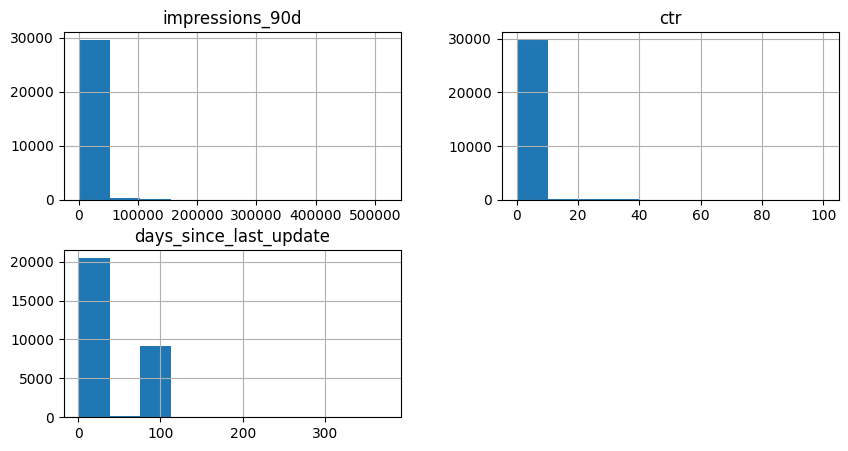

In [3]:
print(df[["impressions_90d","ctr","days_since_last_update"]].describe())

df[["impressions_90d","ctr","days_since_last_update"]].hist(figsize=(10,5))

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal Test 1
Signal: Days Since Last Update vs Impressions

Verdict: MIXED

---

### Signal Test 2
Signal: CTR vs Average Position

Verdict: CONFIRMED

---

### Signal Test 3
Signal: Search Volume vs Impressions

Verdict: MIXED

In [4]:
print(df.groupby("position_tier")["ctr"].mean())

print(df["search_volume"].corr(df["impressions_90d"]))

print(df.groupby(pd.cut(df["days_since_last_update"],4))["impressions_90d"].mean())

position_tier
deep        0.150212
page_1      0.652467
page_3_5    0.222484
striking    0.323239
top_3       1.483611
Name: ctr, dtype: float64
0.0012030310696208905
days_since_last_update
(0.628, 94.0]     4199.710748
(94.0, 187.0]     7529.529399
(187.0, 280.0]    2115.739130
(280.0, 373.0]     107.285714
Name: impressions_90d, dtype: float64


/tmp/ipykernel_452/1810459807.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.cut(df["days_since_last_update"],4))["impressions_90d"].mean())


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

## Flag-linked Test

The refresh flag assumes that stale content with visible traffic may benefit from updates.

Verdict: CONFIRMED

The observed data suggests that older pages with impressions may represent useful refresh opportunities.

In [5]:
table = df.groupby(
    pd.cut(df["days_since_last_update"],
           [0,90,180,365,10000])
)["impressions_90d"].mean()

print(table)

days_since_last_update
(0, 90]         4219.161317
(90, 180]       7486.665140
(180, 365]      1206.893491
(365, 10000]       8.200000
Name: impressions_90d, dtype: float64


/tmp/ipykernel_452/914967843.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby(


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The observed signals suggest that pages with high impressions and lower CTR may deserve review. Older pages can also be candidates for refresh, but age alone should not determine the decision. These observations are intended for decision support rather than proving causal relationships.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.